In [2]:
import pandas as pd
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import numpy as np
from matplotlib import cm, colors
import scipy.stats as ss
import pandas as pd

def underline_max(series):
    """Underline the maximum value(s) in a column."""
    is_max = series == series.max()        # Boolean Series
    return ['text-decoration: underline' if v else '' for v in is_max]

def underline_min(series):
    """Underline the maximum value(s) in a column."""
    is_min = series == series.min()        # Boolean Series
    return ['text-decoration: underline' if v else '' for v in is_min]

def print_pivot_to_latex(pivot_table):
    vmins = pivot_table.min()
    vmaxs = pivot_table.max()

    # --- Lighten the colormap (avoid overly dark greens)
    cmap = cm.get_cmap('Greens')
    def lighten_color_map(val):
        r, g, b, _ = val
        return (0.3 + 0.7 * r, 0.3 + 0.7 * g, 0.3 + 0.7 * b, 1)  # move toward lighter shades

    # --- Find max indices per column for underlining
    max_indices = pivot_table.idxmax()

    def color_cell(val, col):
        # normalize within column
        norm = colors.Normalize(vmin=vmins[col], vmax=vmaxs[col])
        r, g, b, _ = lighten_color_map(cmap(norm(val)))
        cell = f"\\cellcolor[rgb]{{{r:.3f},{g:.3f},{b:.3f}}}{val:.3f}"
        # underline max value per column
        if pivot_table.loc[:, col].idxmax() == idx:
            cell = f"\\underline{{{cell}}}"
        return cell

    # --- Build LaTeX table manually
    rows = []
    for idx, row in pivot_table.iterrows():
        colored = [color_cell(row[col], col) for col in pivot_table.columns]
        rows.append(f"{idx} & " + " & ".join(colored) + " \\\\")

    latex_table = (
        "\\begin{tabular}{l" + "r" * len(pivot_table.columns) + "}\n"
        + "Constraint & " + " & ".join(pivot_table.columns) + " \\\\\n"
        + "\\hline\n"
        + "\n".join(rows)
        + "\n\\end{tabular}"
    )

    print(latex_table)

In [3]:
import glob
import os
import pandas as pd
import scipy.stats as ss
from pathlib import Path

# -------------------------------------------------------
# 1. Load all CSVs into one big DataFrame
# -------------------------------------------------------
data_dir = Path(".")          # <-- change this
csv_paths = sorted(data_dir.glob("*.csv"))

dfs = []
for p in csv_paths:
    if 'suffix' in str(p) :#and 'ND' in str(p):
        print(p)
        df = pd.read_csv(p)
#         print(df.head())
        # Keep the source dataset name (file stem)
        df["dataset"] = p.stem
#         df = df[df.local == False]
        dfs.append(df)
        print(df['seed'].unique())
        
        for seed in df['seed'].unique():
            print(len(df[df['seed']==seed]))

df_all = pd.concat(dfs, ignore_index=True)

results_differo_suffix_BPI12.csv
[  56    8   15   76   23   42    4  108   16 1089]
78
78
78
78
78
78
78
78
78
78
results_differo_suffix_BPI19.csv
[ 8 15 23 56 76]
102
78
78
118
84
results_differo_suffix_BPI20PrepaidTravelCosts.csv
[  56    8   15   76   23   42    4  108   16 1089]
78
78
78
78
78
78
78
78
78
78
results_differo_suffix_BPI20RequestForPayment.csv
[  56    8   15   76   23   42    4  108   16 1089]
78
78
78
78
78
78
78
78
78
78


In [4]:
import glob
import os
import numpy as np
import pandas as pd
import scipy.stats as ss
from pathlib import Path


def make_model_column(row):
    if row['rank_loss'] == True:
        return 'rank_loss'
    if row['sdfa_ce'] == True and row['local']==False:
        return 'SDFA'
    if row['sdfa_ce'] == True:
        return 'SDFA_nonlocal'
    if row['model'] == 'SDFA_NAP_model' and row['local']== True:
        return 'DIFF-ERO_local'
    if row['model'] == 'SDFA_NAP_model':
        return 'DIFF-ERO_notlocal'
    else:
        return 'Base'

# -------------------------------------------------------
# 1. Load all CSVs into one big DataFrame
# -------------------------------------------------------
data_dir = Path(".")          # <-- change this
csv_paths = sorted(data_dir.glob("*.csv"))

dfs = []
for p in csv_paths:
    if 'suffix' in str(p):
        df = pd.read_csv(p)
        # Keep the source dataset name (file stem)
        df["dataset"] = p.stem
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
# df_all = df_all[df_all['local'] == False]
df_all['model'] = df_all.apply(lambda x: make_model_column(x), axis=1)
df_all = df_all.drop(['quantile', 'rank_loss', 'sdfa_ce', 'no_epochs', 'er_loss'], axis=1)

df_all

,seed,local,model,lambda,d_model,batch_size,avg_beam_dl_distance,avg_dl_distance,time,er_pred,er_target,dataset
0,56,False,Base,0.1,16,128,0.509671,0.588193,7.384923,0,0,results_differo_suffix_BPI12
1,56,True,Base,0.1,16,32,0.472376,0.575425,18.187784,0,0,results_differo_suffix_BPI12
2,56,True,Base,0.1,16,64,0.493251,0.580537,12.198710,0,0,results_differo_suffix_BPI12
3,56,True,Base,0.1,16,128,0.502390,0.606196,9.224283,0,0,results_differo_suffix_BPI12
4,56,False,SDFA,0.1,16,128,0.505078,0.598690,7.296565,0,0,results_differo_suffix_BPI12
...,...,...,...,...,...,...,...,...,...,...,...,...
2795,1089,False,Base,0.0,16,128,0.241431,0.321516,2.900931,0,0,results_differo_suffix_BPI20RequestForPayment
2796,1089,False,rank_loss,0.0,32,128,0.270522,0.327480,3.207055,0,0,results_differo_suffix_BPI20RequestForPayment
2797,1089,False,Base,0.0,32,128,0.224150,0.308092,2.895128,0,0,results_differo_suffix_BPI20RequestForPayment
2798,1089,False,rank_loss,0.0,64,128,0.255860,0.318534,3.197353,0,0,results_differo_suffix_BPI20RequestForPayment


In [6]:
# df_local = df_all[df_all['local'] == True]
df_local = df_all
df_local['dataset'] = df_local['dataset'].apply(lambda x: x.replace('results_differo_suffix_', ''))
# df_local = df_local[df_local['d_model'] > 16]
pivot_table = pd.pivot_table(df_local, 
                             values=['avg_dl_distance'], 
                             columns = ['dataset'],
                             index=[ 'local', 'batch_size',  'lambda'], 
                             aggfunc=np.mean)
styled_table = pivot_table.style.background_gradient(cmap='Blues').apply(underline_min, axis=0)
styled_table

/var/folders/rz/s0r_wmmx54b8t4zd9_r9xqbr0000gn/T/ipykernel_27547/2405122424.py:5: FutureWarning: The provided callable <function mean at 0x1060da200> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = pd.pivot_table(df_local,


                   Base      SDFA  SDFA_nonlocal  rank_loss
Base           1.000000  0.692333       0.947190   0.947190
SDFA           0.692333  1.000000       0.947190   0.354318
SDFA_nonlocal  0.947190  0.947190       1.000000   0.692333
rank_loss      0.947190  0.354318       0.692333   1.000000
model
rank_loss        1.75
Base             2.25
SDFA_nonlocal    2.75
SDFA             3.25
dtype: float64


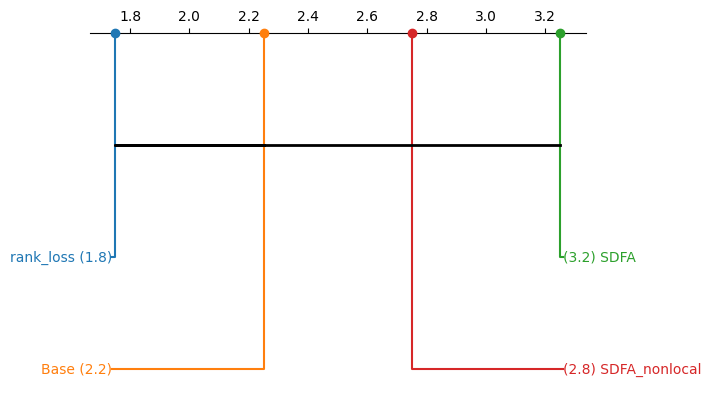

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
import scikit_posthocs as sp
from scipy.stats import rankdata
from scipy.stats import friedmanchisquare

metric = "avg_dl_distance"
# df_all = df_all[df_all["lambda"] < 0.5]
# df_all = df_all[df_all['local'] == True]

df_seed_avg = (
    df_all.groupby([
        "dataset",
        "model",
        "lambda",
        "d_model",
        "batch_size",
    ])[metric]
    .mean()
    .reset_index()
)
df_seed_avg
best_configs = (
    df_seed_avg
    .sort_values(metric, ascending=False)
    .groupby(["dataset", "model"])
    .head(1)
)
pivot = best_configs.pivot(
    index="dataset",
    columns="model",
    values=metric
)
pivot

friedmanchisquare(*[pivot[col] for col in pivot.columns])

nemenyi = sp.posthoc_nemenyi_friedman(pivot)
print(nemenyi)


ranks = pivot.apply(
    lambda row: pd.Series(
        rankdata(-row.values, method="average"),
        index=row.index
    ),
    axis=1
)

avg_ranks = ranks.mean().sort_values()
print(avg_ranks)

sp.critical_difference_diagram(avg_ranks, nemenyi)
plt.show()

In [8]:
import glob
import os
import pandas as pd
import scipy.stats as ss
from pathlib import Path

# -------------------------------------------------------
# 1. Load all CSVs into one big DataFrame
# -------------------------------------------------------
data_dir = Path(".")          # <-- change this
csv_paths = sorted(data_dir.glob("*.csv"))

dfs = []
for p in csv_paths:
    if 'suffix' in str(p):
        df = pd.read_csv(p)
        # Keep the source dataset name (file stem)
        df["dataset"] = p.stem
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# -------------------------------------------------------
# 2. Basic filtering
# -------------------------------------------------------
# df_all = df_all[df_all["lambda"] < 0.5]
# df_all = df_all[df_all['local'] == False]

# -------------------------------------------------------
# 3. Keep only the metrics we care about
# -------------------------------------------------------
cols_needed = ["dataset", "seed", "model", "d_model", 'sdfa_ce', 'rank_loss', "lambda", "avg_dl_distance"]
df_all = df_all[cols_needed]

# -------------------------------------------------------
# 4. Find the best parameter setting per seed–model–dataset
# -------------------------------------------------------
best = (
    df_all
    .sort_values("avg_dl_distance", ascending=False)          # highest f1 first
    .drop_duplicates(subset=["dataset", "seed", "model", 'sdfa_ce', 'rank_loss',], keep="first")
    .reset_index(drop=True)
)

# -------------------------------------------------------
# 5. Average metrics over seeds, grouped by dataset & model
# -------------------------------------------------------
summary = (
    best
    .groupby(["dataset", "model", 'sdfa_ce', 'rank_loss',], as_index=False)
    .agg(
        f1_mean=("avg_dl_distance", "mean")
    )
)

# -------------------------------------------------------
# 6. Pivot so that each model becomes a column
# -------------------------------------------------------
pivot_f1 = summary.pivot(index="dataset", columns=["model", 'sdfa_ce', 'rank_loss'], values=["f1_mean"])
# pivot_prec = summary.pivot(index="dataset", columns="model", values="precision_mean")
pd.set_option("display.precision", 3)
pivot_f1

# -------------------------------------------------------
# 7. Statistical test per dataset
# -------------------------------------------------------
# 7a. Build a DataFrame with the two model columns side‑by‑side
# model_a, model_b = sorted(df_all["model"].unique())  # ensure consistent order
# tests = []

# for ds in df_all["dataset"].unique():
#     sub = best[best["dataset"] == ds]
# #     if len(shared_seeds) < 3:   # Wilcoxon needs at least 3 pairs
# #         continue
#     vals_a = sub[sub["model"] == model_a].sort_values("seed")["f1"].values
#     vals_b = sub[sub["model"] == model_b].sort_values("seed")["f1"].values
#     stat, p = ss.wilcoxon(vals_a - vals_b)   # difference a – b
#     tests.append({"dataset": ds,
#                   "stat": stat,
#                   "p": p,
#                   f"{model_a}_mean": vals_a.mean(),
#                   f"{model_b}_mean": vals_b.mean()})

# tests_df = pd.DataFrame(tests)
# pd.set_option("display.precision", 3)

# # a) Merge the metric pivots with the test results
# final_table = pivot_f1.copy()
# print(final_table)
# final_table.columns = [f"{c}_f1" for c in final_table.columns]
# final_table = final_table.merge(
#     pivot_prec.rename(columns={c: f"{c}_prec" for c in pivot_prec.columns}),
#     left_index=True, right_index=True
# )
# print(final_table)
# # final_table = final_table.merge(tests_df[["dataset", "p"]], left_index=True, right_index=True)
# final_table
# # print(final_table)

f1_mean         \
model                                          SDFA_suffix_model          
sdfa_ce                                                    False  True    
rank_loss                                                  False  False   
dataset                                                                   
results_differo_suffix_BPI12                               0.601  0.599   
results_differo_suffix_BPI19                               0.432  0.425   
results_differo_suffix_BPI20PrepaidTravelCosts             0.406  0.406   
results_differo_suffix_BPI20RequestForPayment              0.329  0.334   

                                                                    
model                                          suffix_model         
sdfa_ce                                               False         
rank_loss                                             False  True   
dataset                                                             
results_differo_suffix_BPI12                          0.567  0.897  
results_differo_suffix_BPI19                          0.405  0.368  
results_differo_suffix_BPI20PrepaidTravelCosts        0.382  0.745  
results_differo_suffix_BPI20RequestForPayment         0.321  0.389

In [4]:
df_all

,seed,local,quantile,model,lambda,d_model,er_loss,batch_size,no_epochs,rank_loss,sdfa_ce,avg_beam_dl_distance,avg_dl_distance,time,er_pred,er_target,dataset
0,56,False,0.8,SDFA_suffix_model,0.1,16,True,128,50,False,False,0.509671,0.588193,7.384923,0,0,results_differo_suffix_BPI12
1,56,True,0.8,SDFA_suffix_model,0.1,16,True,32,50,False,False,0.472376,0.575425,18.187784,0,0,results_differo_suffix_BPI12
2,56,True,0.8,SDFA_suffix_model,0.1,16,True,64,50,False,False,0.493251,0.580537,12.198710,0,0,results_differo_suffix_BPI12
3,56,True,0.8,SDFA_suffix_model,0.1,16,True,128,50,False,False,0.502390,0.606196,9.224283,0,0,results_differo_suffix_BPI12
4,56,False,0.8,SDFA_suffix_model,0.1,16,True,128,50,False,True,0.505078,0.598690,7.296565,0,0,results_differo_suffix_BPI12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2335,1089,False,0.8,suffix_model,0.0,16,False,128,50,False,False,0.241431,0.321516,2.900931,0,0,results_differo_suffix_BPI20RequestForPayment
2336,1089,False,0.8,suffix_model,0.0,32,False,128,50,True,False,0.270522,0.327480,3.207055,0,0,results_differo_suffix_BPI20RequestForPayment
2337,1089,False,0.8,suffix_model,0.0,32,False,128,50,False,False,0.224150,0.308092,2.895128,0,0,results_differo_suffix_BPI20RequestForPayment
2338,1089,False,0.8,suffix_model,0.0,64,False,128,50,True,False,0.255860,0.318534,3.197353,0,0,results_differo_suffix_BPI20RequestForPayment


In [5]:
for p in csv_paths:
    if 'suffix' in str(p) and 'ns' not in str(p):
        print(p)
        
        df = pd.read_csv(p)
        # df = df[df['lambda']<0.5]
        df = df[df['local'] == False]

        df_test = df[['seed', 'model', 'd_model', 'avg_dl_distance']]

        df_test = (
            df_test
            .groupby(['seed', 'model'])
            .agg(f1_mean=('avg_dl_distance', 'max'))
            .reset_index()
        )

        sub = df_test
        pivot = sub.pivot(index='seed', columns='model', values='f1_mean')
        print(pivot)
        stat, p = ss.wilcoxon(pivot['SDFA_suffix_model']-pivot['suffix_model'])
        print(stat)
        print(p)


results_differo_suffix_BPI12.csv
model  SDFA_suffix_model  suffix_model
seed                                  
4               0.614765      0.901262
8               0.601490      0.902883
15              0.594530      0.883673
16              0.580610      0.903627
23              0.600693      0.887067
42              0.649569      0.903538
56              0.610568      0.898292
76              0.582416      0.898292
108             0.575667      0.901262
1089            0.599551      0.894605
0.0
0.001953125
results_differo_suffix_BPI20PrepaidTravelCosts.csv
model  SDFA_suffix_model  suffix_model
seed                                  
4               0.411561      0.734104
8               0.398190      0.613729
15              0.424164      0.809205
16              0.390264      0.676042
23              0.402346      0.899661
42              0.404708      0.899223
56              0.418189      0.707394
76              0.406528      0.648984
108             0.404711      0.620676
108

In [19]:
import glob
import os
import pandas as pd
import scipy.stats as ss
from pathlib import Path

# -------------------------------------------------------
# 1. Load all CSVs into one big DataFrame
# -------------------------------------------------------
data_dir = Path(".")          # <-- change this
csv_paths = sorted(data_dir.glob("*.csv"))

dfs = []
for p in csv_paths:
    if 'suffix' in str(p) and 'not_local' in str(p):
        df = pd.read_csv(p)
        # Keep the source dataset name (file stem)
        df["dataset"] = p.stem
        df['er_diff'] = (df['er_pred'] - df['er_target']) / (df['er_pred'])
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# -------------------------------------------------------
# 2. Basic filtering
# -------------------------------------------------------
# df_all = df_all[df_all["lambda"] < 0.5]
df_all = df_all[df_all['local'] == False]

# -------------------------------------------------------
# 3. Keep only the metrics we care about
# -------------------------------------------------------
cols_needed = ["dataset", "seed", "model", "d_model", "lambda", "avg_dl_distance", "er_diff"]
df_all = df_all[cols_needed]

# -------------------------------------------------------
# 4. Find the best parameter setting per seed–model–dataset
# -------------------------------------------------------
best = (
    df_all
    .sort_values("avg_dl_distance", ascending=False)          # highest f1 first
    .drop_duplicates(subset=["dataset", "seed", "model"], keep="first")
    .reset_index(drop=True)
)

# -------------------------------------------------------
# 5. Average metrics over seeds, grouped by dataset & model
# -------------------------------------------------------
summary = (
    best
    .groupby(["dataset", "model"], as_index=False)
    .agg(
        f1_mean=("avg_dl_distance", "mean"),
        precision_mean=("er_diff", "mean")
    )
)

# -------------------------------------------------------
# 6. Pivot so that each model becomes a column
# -------------------------------------------------------
pivot_f1 = summary.pivot(index="dataset", columns="model", values="f1_mean")
pivot_prec = summary.pivot(index="dataset", columns="model", values="precision_mean")

print(pivot_f1)

# -------------------------------------------------------
# 7. Statistical test per dataset
# -------------------------------------------------------
# 7a. Build a DataFrame with the two model columns side‑by‑side
model_a, model_b = sorted(df_all["model"].unique())  # ensure consistent order
tests = []

for ds in df_all["dataset"].unique():
    sub = best[best["dataset"] == ds]
#     if len(shared_seeds) < 3:   # Wilcoxon needs at least 3 pairs
#         continue
    vals_a = sub[sub["model"] == model_a].sort_values("seed")["avg_dl_distance"].values
    vals_b = sub[sub["model"] == model_b].sort_values("seed")["avg_dl_distance"].values
    stat, p = ss.wilcoxon(vals_a - vals_b)   # difference a – b
    tests.append({"dataset": ds,
                  "stat": stat,
                  "p": p,
                  f"{model_a}_mean": vals_a.mean(),
                  f"{model_b}_mean": vals_b.mean()})

tests_df = pd.DataFrame(tests)
pd.set_option("display.precision", 3)

# a) Merge the metric pivots with the test results
final_table = pivot_f1.copy()
print(final_table)
final_table.columns = [f"{c}_dl" for c in final_table.columns]
final_table = final_table.merge(
    pivot_prec.rename(columns={c: f"{c}_er" for c in pivot_prec.columns}),
    left_index=True, right_index=True
)
print(final_table)
# final_table = final_table.merge(tests_df[["dataset", "p"]], left_index=True, right_index=True)
final_table
# print(final_table)

model                                               SDFA_suffix_model  \
dataset                                                                 
results_suffix_prediction_not_local_BPI12                       0.692   
results_suffix_prediction_not_local_BPI17                       0.620   
results_suffix_prediction_not_local_BPI19                       0.435   
results_suffix_prediction_not_local_BPI20Prepai...              0.470   
results_suffix_prediction_not_local_BPI20Reques...              0.357   
results_suffix_prediction_not_local_BPI20Travel...              0.516   

model                                               suffix_model  
dataset                                                           
results_suffix_prediction_not_local_BPI12                  0.669  
results_suffix_prediction_not_local_BPI17                  0.599  
results_suffix_prediction_not_local_BPI19                  0.431  
results_suffix_prediction_not_local_BPI20Prepai...         0.403  
results_suffi

,SDFA_suffix_model_dl,suffix_model_dl,SDFA_suffix_model_er,suffix_model_er
dataset,,,,
results_suffix_prediction_not_local_BPI12,0.692,0.669,4.797e-03,NaN
results_suffix_prediction_not_local_BPI17,0.620,0.599,2.212e-03,NaN
results_suffix_prediction_not_local_BPI19,0.435,0.431,4.465e-02,NaN
results_suffix_prediction_not_local_BPI20PrepaidTravelCosts,0.470,0.403,5.302e-06,NaN
results_suffix_prediction_not_local_BPI20RequestForPayment,0.357,0.329,1.559e-02,NaN
results_suffix_prediction_not_local_BPI20TravelPermitData,0.516,0.497,2.147e-02,NaN


In [9]:
import glob
import os
import pandas as pd
import scipy.stats as ss
from pathlib import Path

# -------------------------------------------------------
# 1. Load all CSVs into one big DataFrame
# -------------------------------------------------------
data_dir = Path(".")          # <-- change this
csv_paths = sorted(data_dir.glob("*.csv"))

dfs = []
for p in csv_paths:
    if 'suffix' in str(p):# and 'ND' in str(p):
        df = pd.read_csv(p)
        # Keep the source dataset name (file stem)
        df["dataset"] = p.stem
#         df['er_diff'] = (df['er_pred'] - df['er_target']) / (df['er_pred'])
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# -------------------------------------------------------
# 2. Basic filtering
# -------------------------------------------------------
# df_all = df_all[df_all["lambda"] < 0.5]
# df_all = df_all[df_all['local'] == False]

# -------------------------------------------------------
# 3. Keep only the metrics we care about
# -------------------------------------------------------
cols_needed = ["dataset", "seed", "model", "d_model", "lambda", 'sdfa_ce', 'rank_loss', "avg_dl_distance"]
df_all = df_all[cols_needed]

# -------------------------------------------------------
# 4. Find the best parameter setting per seed–model–dataset
# -------------------------------------------------------
best = (
    df_all
    .sort_values("avg_dl_distance", ascending=False)          # highest f1 first
    .drop_duplicates(subset=["dataset", "seed", "model", 'sdfa_ce', 'rank_loss'], keep="first")
    .reset_index(drop=True)
)

# -------------------------------------------------------
# 5. Average metrics over seeds, grouped by dataset & model
# -------------------------------------------------------
summary = (
    best
    .groupby(["dataset", "model", 'sdfa_ce', 'rank_loss'], as_index=False)
    .agg(
        f1_mean=("avg_dl_distance", "min"),
    )
)

# -------------------------------------------------------
# 6. Pivot so that each model becomes a column
# -------------------------------------------------------
pivot_f1 = summary.pivot(index="dataset", columns=["model", 'sdfa_ce', 'rank_loss'], values="f1_mean")


pivot_f1

# # -------------------------------------------------------
# # 7. Statistical test per dataset
# # -------------------------------------------------------
# # 7a. Build a DataFrame with the two model columns side‑by‑side
# model_a, model_b = sorted(df_all["model"].unique())  # ensure consistent order
# tests = []

# for ds in df_all["dataset"].unique():
#     sub = best[best["dataset"] == ds]
# #     if len(shared_seeds) < 3:   # Wilcoxon needs at least 3 pairs
# #         continue
#     vals_a = sub[sub["model"] == model_a].sort_values("seed")["avg_dl_distance"].values
#     vals_b = sub[sub["model"] == model_b].sort_values("seed")["avg_dl_distance"].values
#     stat, p = ss.wilcoxon(vals_a - vals_b)   # difference a – b
#     tests.append({"dataset": ds,
#                   "stat": stat,
#                   "p": p,
#                   f"{model_a}_mean": vals_a.mean(),
#                   f"{model_b}_mean": vals_b.mean()})

# tests_df = pd.DataFrame(tests)
# pd.set_option("display.precision", 3)

# # a) Merge the metric pivots with the test results
# final_table = pivot_f1.copy()
# print(final_table)
# final_table.columns = [f"{c}_dl" for c in final_table.columns]
# final_table = final_table.merge(
#     pivot_prec.rename(columns={c: f"{c}_er" for c in pivot_prec.columns}),
#     left_index=True, right_index=True
# )
# print(final_table)
# # final_table = final_table.merge(tests_df[["dataset", "p"]], left_index=True, right_index=True)
# final_table
# # print(final_table)

model                                          SDFA_suffix_model            \
sdfa_ce                                                    False     True    
rank_loss                                                  False     False   
dataset                                                                      
results_differo_suffix_BPI12                            0.577229  0.570488   
results_differo_suffix_BPI20PrepaidTravelCosts          0.392825  0.393403   
results_differo_suffix_BPI20RequestForPayment           0.309011  0.312390   

model                                          suffix_model            
sdfa_ce                                               False            
rank_loss                                             False     True   
dataset                                                                
results_differo_suffix_BPI12                       0.543531  0.883673  
results_differo_suffix_BPI20PrepaidTravelCosts     0.376239  0.613729  
results_differo_suffix_BPI20RequestForPayment      0.308299  0.327400

In [5]:
import pandas as pd
import numpy as np
from matplotlib import cm, colors

df = pd.read_csv('results_differo_suffix_BPI20PrepaidTravelCosts.csv')
df = df[df['local']==False]
pivot_table = pd.pivot_table(df, 
                             values=['avg_dl_distance'], 
                             
                             index=['local', 'batch_size', 'sdfa_ce', 'rank_loss', 'model', 'd_model', 'lambda'], 
                             aggfunc=np.mean)
styled_table = pivot_table.style.background_gradient(cmap='Blues').apply(underline_min, axis=0)
styled_table

/var/folders/rz/s0r_wmmx54b8t4zd9_r9xqbr0000gn/T/ipykernel_3539/860991831.py:7: FutureWarning: The provided callable <function mean at 0x106ada2a0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = pd.pivot_table(df,


In [12]:
import pandas as pd
import numpy as np
from matplotlib import cm, colors

df = pd.read_csv('results_suffix_prediction_ND_BPI20PrepaidTravelCosts.csv')
df = df[df['local']==False]
pivot_table = pd.pivot_table(df, 
                             values=['avg_dl_distance'], 
                             
                             index=['local', 'batch_size', 'sdfa_ce', 'rank_loss', 'model', 'd_model', 'lambda'], 
                             aggfunc=np.mean)
styled_table = pivot_table.style.background_gradient(cmap='Blues').apply(underline_min, axis=0)
styled_table

/var/folders/rz/s0r_wmmx54b8t4zd9_r9xqbr0000gn/T/ipykernel_73600/1006701482.py:7: FutureWarning: The provided callable <function mean at 0x107fda200> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = pd.pivot_table(df,


In [11]:
import pandas as pd
import numpy as np
from matplotlib import cm, colors

df = pd.read_csv('results_suffix_prediction_BPI20RequestForPayment.csv')

df = df[df['batch_size']<30]
pivot_table = pd.pivot_table(df, 
                             values=['avg_dl_distance'], 
                             
                             index=['local', 'batch_size', 'model', 'd_model', 'lambda'], 
                             aggfunc=np.mean)
styled_table = pivot_table.style.background_gradient(cmap='Blues').apply(underline_min, axis=0)
styled_table

/var/folders/rz/s0r_wmmx54b8t4zd9_r9xqbr0000gn/T/ipykernel_67180/948701201.py:8: FutureWarning: The provided callable <function mean at 0x1107c65c0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = pd.pivot_table(df,


In [15]:
import pandas as pd
import numpy as np
from matplotlib import cm, colors

df = pd.read_csv('results_suffix_prediction_BPI12.csv')

df = df[df['batch_size']<30]
pivot_table = pd.pivot_table(df, 
                             values=['avg_dl_distance'], 
                             
                             index=['local', 'batch_size', 'model', 'd_model', 'lambda'], 
                             aggfunc=np.mean)
styled_table = pivot_table.style.background_gradient(cmap='Blues').apply(underline_min, axis=0)
styled_table

/var/folders/rz/s0r_wmmx54b8t4zd9_r9xqbr0000gn/T/ipykernel_67180/4148795791.py:8: FutureWarning: The provided callable <function mean at 0x1107c65c0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_table = pd.pivot_table(df,
